Epoch 0: Loss = 1.0035
Epoch 10: Loss = 0.9995
Epoch 20: Loss = 0.9972
Epoch 30: Loss = 0.9902
Epoch 40: Loss = 0.9817
Epoch 49: Loss = 0.9724
Saved decision boundary plot.


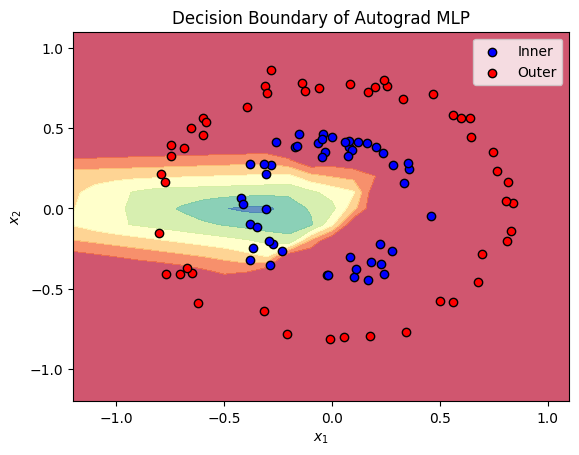

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Seed for reproducibility
random.seed(42)
np.random.seed(42)

class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), 'ReLU')
        def _backward():
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __neg__(self): return self * -1

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu()

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

# Generate Dataset (Moons-like or simple concentric circles)
def make_circles(n_samples=100, noise=0.05):
    X = []
    y = []
    for _ in range(n_samples // 2):
        # Inner circle
        r = 0.4 + random.normalvariate(0, noise)
        theta = random.uniform(0, 2 * np.pi)
        X.append([r * np.cos(theta), r * np.sin(theta)])
        y.append(1.0)
        
        # Outer circle
        r = 0.8 + random.normalvariate(0, noise)
        theta = random.uniform(0, 2 * np.pi)
        X.append([r * np.cos(theta), r * np.sin(theta)])
        y.append(-1.0)
    return X, y

X, y = make_circles(100)

# Initialize network: 2 inputs, hidden layers [8, 8], 1 output
model = MLP(2, [8, 8, 1])

# Training loop
epochs = 50
learning_rate = 0.05

for k in range(epochs):
    # Forward pass
    total_loss = Value(0.0)
    for xi, yi in zip(X, y):
        pred = model(xi)
        # Max-margin / Hinge loss: max(0, 1 - y * pred)
        # Let's use squared error for smoothness or hinge loss
        loss = (pred - yi)**2
        total_loss = total_loss + loss
    
    total_loss = total_loss * (1.0 / len(X))
    
    # Zero gradients
    for p in model.parameters():
        p.grad = 0.0
        
    # Backward pass
    total_loss.backward()
    
    # Update parameters
    for p in model.parameters():
        p.data -= learning_rate * p.grad
        
    if k % 10 == 0 or k == epochs - 1:
        print(f"Epoch {k}: Loss = {total_loss.data:.4f}")

# Plotting the decision boundary
h = 0.1
x_min, x_max = -1.2, 1.2
y_min, y_max = -1.2, 1.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = []
for x1, x2 in zip(xx.ravel(), yy.ravel()):
    pred = model([x1, x2])
    Z.append(pred.data)
Z = np.array(Z).reshape(xx.shape)

# Create plot
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
X_np = np.array(X)
y_np = np.array(y)
plt.scatter(X_np[y_np==1][:,0], X_np[y_np==1][:,1], c='blue', label='Inner', edgecolors='k')
plt.scatter(X_np[y_np==-1][:,0], X_np[y_np==-1][:,1], c='red', label='Outer', edgecolors='k')
plt.title("Decision Boundary of Autograd MLP")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.savefig("decision_boundary.png")
print("Saved decision boundary plot.")